In [233]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import tkinter as tk
from tkinter import filedialog, ttk

In [234]:
input_dir = 'test-images'
output_dir = 'results'

In [235]:
def preprocess_image(image_path):
    ## load and preprocess image for circle detection
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0) # 0 is the sigma value
    

    return img, gray

    

In [236]:
def plot_image(img, output):
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Image')
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected Circles')
    plt.show()

In [237]:
def detect_circles(gray):
    ## detect circles using HoughCircles\
    circles = cv2.HoughCircles(gray, 
                               cv2.HOUGH_GRADIENT, 
                               dp=1, 
                               minDist=20,
                               param1=50,
                               param2=60,
                               minRadius=0,
                               maxRadius=0)
    return circles[0] if circles is not None else []


In [238]:
def visualize_circles(img, circles, save_path=None):
    ## draw detected circles on the image
    output = img.copy()
    for (x, y, r) in circles:
        x = int(x)
        y = int(y)
        r = int(r)
        
        cv2.circle(output, (x, y), r, (0, 255, 0), 4) # circle outline
        cv2.rectangle(output, (x - 5, y - 5), (x + 5, y + 5), (0, 0, 255), -1) # circle center

    if save_path:
        cv2.imwrite(save_path, output)
        print(f"Image with detected circles saved at: {save_path}")

    return output

In [239]:
def calculate_statistics(circles):
    ## calculate statistics of detected circles

    ## save statistics to a text file
    radii = [r for (x,y,r) in circles]
    if len(radii) == 0:
        return 0, 0, 0
    mean_radius = np.mean(radii)
    min_radius = np.min(radii)
    max_radius = np.max(radii)
    ## returns a dictionary of statistics
    stats = {
        "mean radius": mean_radius,
        "min radius": min_radius,
        "max radius": max_radius,
        "# circles": len(radii),
        
    }
    return stats

In [240]:
def main():
    img_path = input("Enter the file name of the image: ").strip()
    if not img_path:
        img_path = 'sample_image1.jpeg' #default image
        
    img_path = os.path.join(input_dir, img_path)
    
    img, preprocessed_img = preprocess_image(img_path)
    circles = detect_circles(preprocessed_img)
    output = visualize_circles(img, detect_circles(preprocessed_img), save_path = os.path.join(output_dir,'circles_' + os.path.basename(img_path)))
    plot_image(img, output)

    # write statistics to a text file
    stats = calculate_statistics(circles)
    stats_file = os.path.join(output_dir, 'statistics.txt')
    with open(stats_file, 'a') as f:
        f.write(f"Image: {os.path.basename(img_path)}\n")
        for key, value in stats.items():
            f.write(f"{key}: {value}\n")
        f.write("\n")
    print(f"Statistics saved at: {stats_file}")
    
    

Image with detected circles saved at: results\circles_sample_image1.jpeg


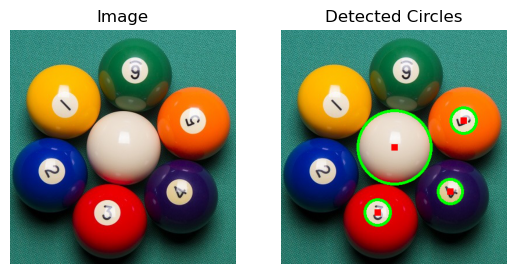

Statistics saved at: results\statistics.txt


In [241]:
if __name__=="__main__":
    main()